<a href="https://colab.research.google.com/github/kmardamb/DATA-205-Spring-2026/blob/main/Project2_KarimM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Title

Project 2

Data 201 Spring 2026

Karim MardamBey

Car Prices Prediction based on Brand, Model, and Year

## 2. Project Introduction

For Project 2 I will be analyzing a dataset of a variety of car prices by manufacturer with the intenet of using the models to predict if the entry level prices of cars has increased over the years. Each observation is a specific car model within that year, the dataset cited below is compiled for educational and research purposes using real world data. A big limitation of the data set is that although specific models are entered in the data set, the variables that would alter prices are not. So things like model trim, mileage, condition, etc. are not in the data set limiting the models ability to fully determine the price of cars in the future.

Huang, Jingmin (2022). DVM-CAR Dataset. figshare. Figure. https://doi.org/10.6084/m9.figshare.19586296.v2

## 3. Data Overview

The dataset has 6,333 rows and 5 columns. Every row is a specific car manufaturer for a specific year. The dataset has both categorical and quantitative variables. Make, Genmodel, Genmodel_ID are categorical variables and Year and Entry_price are quantitative variables. I removed any NAs if there were, and then turned Genmodel into variables that could be used for the regression model.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [23]:
df = pd.read_csv("price_table.csv")
df.head()

,Maker,Genmodel,Genmodel_ID,Year,Entry_price
0,Abarth,124 Spider,2_1,2016,29365
1,Abarth,124 Spider,2_1,2017,26665
2,Abarth,124 Spider,2_1,2018,26665
3,Abarth,124 Spider,2_1,2019,29515
4,Abarth,500,2_2,2009,13400


In [8]:
df.shape

(6333, 5)

In [9]:
df = df.dropna()

In [10]:
df_model = pd.get_dummies(df, columns = ["Maker", "Genmodel"], drop_first = True)

## Data Overview

The dataset has 5 columns and 6333 rows.

Each row represents a car manufacture

The type of variables are: The Maker, the Genmodel, the Genmodel_ID, Manufacturing Year, and Entry Price.


| Variable | Type | Description |
|---|---|---|
| Maker | Categorical | Car manufacturer or brand |
| Genmodel | Categorical | General car model name |
| Genmodel_ID | Categorical | ID number for each model |
| Year | Quantitative | Year of the vehicle model |
| Entry_price | Quantitative | Starting price of the car |

## 4. Data Analysis and Modeling

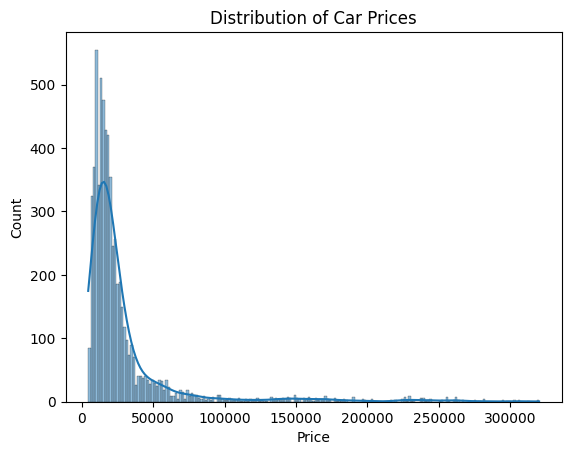

In [11]:
sns.histplot(df["Entry_price"], kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

## a. The histogram shows that a large majority of the car manufactures at an entry level cost approximately <= $50,000 showing a right skewed histogram.

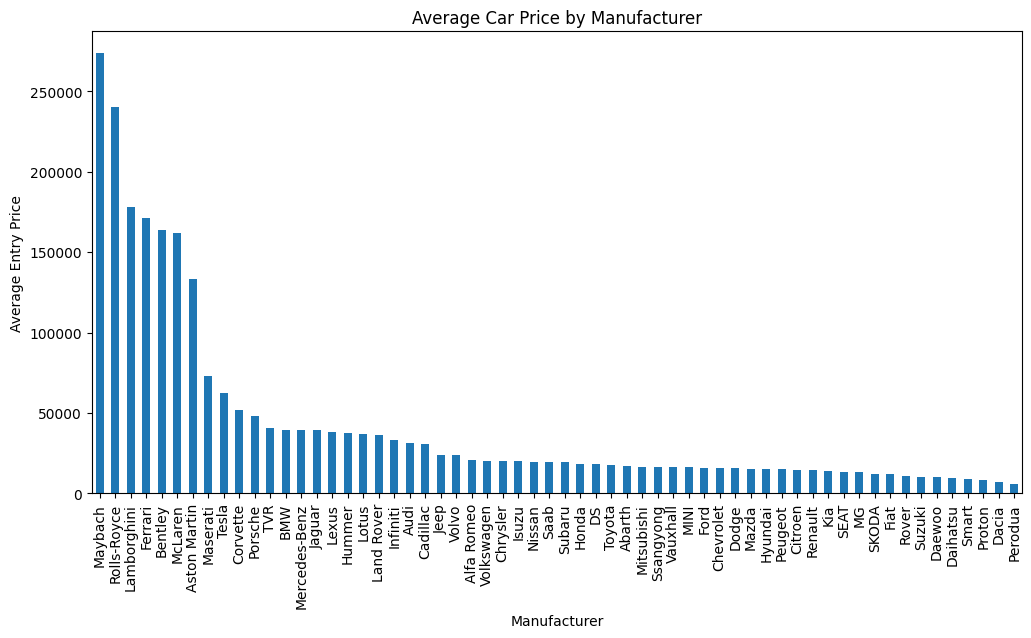

In [12]:
avg_price_maker = df.groupby("Maker")["Entry_price"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
avg_price_maker.plot(kind="bar")

plt.title("Average Car Price by Manufacturer")
plt.xlabel("Manufacturer")
plt.ylabel("Average Entry Price")
plt.xticks(rotation=90)

plt.show()

## a. The barchart above shows the relationship between the specific manufactures and the cost of the vehicle. We can see that luxury vechicles have a larger entry price in comparison to standard base level entry vehicles.

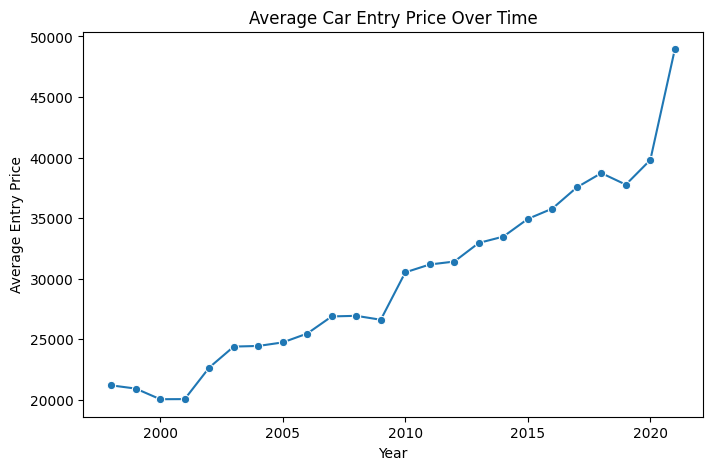

In [24]:
avg_price_year = df.groupby("Year")["Entry_price"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=avg_price_year, x="Year", y="Entry_price", marker="o")

plt.title("Average Car Entry Price Over Time")
plt.xlabel("Year")
plt.ylabel("Average Entry Price")

plt.show()

## a. The line plot above shows the increase of prices of vehicles over the past 2 decades. We can see that the entry level prices in 2000 was approx. 20,000, while in 2020 prices surged to almost 50,000 dollars. This chart supports the claim that car prices have increased by year, and will continue to increase.

## Train / Test Split

For the training and test split, I used a 80/20 percent split, that uses 80% of the data to train the model. This allows for the model to properly predict future data with out the need to overwhelm the model.

In [25]:
X = df_model.drop("Entry_price", axis=1)
y = df_model["Entry_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

In [28]:
model = LinearRegression()
model.fit(X_train, y_train)

baseline_preds = model.predict(X_test)

The baseline model was trained on the cars Year, Maker, and Genmodel. This helps predict the future entry price over the years ahead.

In [29]:
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
baseline_r2 = r2_score(y_test, baseline_preds)

print("Baseline RMSE:", baseline_rmse)
print("Baseline R2:", baseline_r2)

Baseline RMSE: 5807.158831885437
Baseline R2: 0.9799042543044106


The baseline model RMSE is: 5807.158, and the baseline R2 is: 0.979904.

In [31]:
y_log = np.log(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train, y_train)

log_preds = model2.predict(X_test)

In [32]:
preds_improved = np.exp(log_preds)
actual_values = np.exp(y_test)

In [33]:
improved_rmse = np.sqrt(mean_squared_error(actual_values, preds_improved))
improved_r2 = r2_score(actual_values, preds_improved)

print("Improved RMSE:", improved_rmse)
print("Improved R2:", improved_r2)

Improved RMSE: 5802.168829007391
Improved R2: 0.9799387754009248


I used a log transformation to reduce the amount of overpriced vehicles in the model, allowing for a better prediction on average entry priced vehicles and manufacturers. The improved RMSE is: 5802.168, and the improved R2 is: 0.979938.

In [34]:
comparison = pd.DataFrame({

    "Model": ["Baseline", "Improved (Log)"],
    "RMSE": [baseline_rmse, improved_rmse],
    "R2": [baseline_r2, improved_r2]
})

comparison

,Model,RMSE,R2
0,Baseline,5807.158832,0.979904
1,Improved (Log),5802.168829,0.979939


Both models were compared using RMSE and R^2, RMSE calculates the average prediction error between values, R^2 is used to measure the variation in price by model.

In [35]:
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model2.coef_
})

coef_df.sort_values(by="Coefficient", ascending=False).head(10)

,Variable,Coefficient
46,Maker_Rolls-Royce,1.883986
17,Maker_Ferrari,1.708109
35,Maker_Maybach,1.703922
6,Maker_Bentley,1.619607
28,Maker_Lamborghini,1.600126
3,Maker_Aston Martin,1.517769
37,Maker_McLaren,1.353439
329,Genmodel_GT-R,1.351473
507,Genmodel_R8,1.151787
401,Genmodel_Land Cruiser Amazon,1.121187


## Interpret Final Model:

 The final model shows that a vehicle's manufacturer, year, and model are important parts to predict future entry prices for consumers. The logarithmic transformation, predicts the yearly change by taking a years entry price coefficent and then associating it with the predicted price change (interpreted by percentage changes).

In [36]:
sample = X_test.head(3)

predictions = model2.predict(sample)
predictions = np.exp(predictions)

print(predictions)

[ 9620.41666652 35544.75353981 17896.90875992]


## Predictions:

The final model predicted the future entry prices for 3 cars from the initial test set. Cars that belong to luxurious car manufacturers or that are newer models (by year) are predicted to have higher entry prices.

## Conclusions and Recommendations:

For Project 2 I used a linear regression model to predict what the estimated costs of vehicles would be in the future based on year, model and price. For the three data visuals that I used, they all show a consistant trend in car prices based on either year or model, and the prices of entry level cars has increased over the last 20 years. The model did a reasonable job of predicting future entry prices, the improved model did a slightly better job using logarithmic transformation to get better accuracy. The main limitation was the lack of specific data on why car prices were increasing, should better detail if those factors are external (global impact) or specific to the car (mileage, ownership, damage if any, etc). Generally the model did well with the test set, but for future models it would be better to have a more detailed set or with more experience be able to create more complex models.